## In- and out-of-phase form stress (amplitude) at each layer

In [1]:
%matplotlib inline

import datetime, time
import numpy as np
import xesmf as xe
import xarray as xr
import netCDF4 as nc
import cmocean as cm
import matplotlib.ticker
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter, uniform_filter

from gsw import f
from pathlib import Path
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

import warnings
warnings.filterwarnings('ignore')

### construct in- and out-of-phase form stress from amplitude and phase

In [2]:
data_path = Path("/g/data/nm03/lxy581/evaluate/amp_phase")
data_stress = data_path / "form_stress_amp_pha_test_013.nc"
data_vel_u = data_path / "form_u_amp_pha_test_013.nc"
data_vel_v = data_path / "form_v_amp_pha_test_013.nc"

stress = xr.open_dataset(data_stress)
vel_u  = xr.open_dataset(data_vel_u)
vel_v  = xr.open_dataset(data_vel_v)

In [3]:
dep_file = data_path / "depth_h2u_8km.nc"

dep_interp = xr.open_dataset(dep_file)
depth_u = dep_interp.depthu
depth_v = dep_interp.depthv

In [4]:
out_path = Path("/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_x02/output014")
out_grid = out_path / "ocean_static.nc"

static = xr.open_dataset(out_grid)
geolon_u = static.geolon_u
geolat_u = static.geolat_u
geolon_v = static.geolon_v
geolat_v = static.geolat_v

In [5]:
stress_amp_x = stress.amp_x
stress_pha_x = stress.phase_x
u_pha = vel_u.phase_x

In [6]:
stress_amp_y = stress.amp_y
stress_pha_y = stress.phase_y
v_pha = vel_v.phase_y

In [7]:
N_data = xr.open_dataset("/g/data/nm03/lxy581/WOA18/Nave_500m_woa18_interp2u.nc")
N_u = N_data.N_u
N_v = N_data.N_v

### mode-1 wavelength

In [8]:
omega = 2 * np.pi / (12.4206014*3600)

f_u = f(geolat_u) # rad/s
k_u = np.sqrt((omega**2-f_u**2)*np.pi**2/N_u**2/depth_u**2)
lambda_u = 2 * np.pi / k_u / 1000

f_v = f(geolat_v) # rad/s
k_v = np.sqrt((omega**2-f_v**2)*np.pi**2/N_v**2/depth_v**2)
lambda_v = 2 * np.pi / k_v / 1000

In [9]:
lambda_u

<xarray.DataArray (yh: 3270, xq: 4321)> Size: 113MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3270, 4321))
Coordinates:
  * yh       (yh) float64 26kB -89.96 -89.88 -89.79 -89.71 ... 89.91 89.95 89.98
  * xq       (xq) float64 35kB -300.0 -299.9 -299.8 -299.8 ... 59.83 59.92 60.0
    lon_u    (yh, xq) float32 57MB ...
    lat_u    (yh, xq) float32 57MB ...
Attributes:
    interp_method:  none
    cell_measures:  area: areacello
    standard_name:  sea_floor_depth_below_geoid

In [10]:
lambda_mean = np.nanmean(lambda_u)

### x direction, in-phase form stress

In [11]:
x_in = stress_amp_x * np.cos(stress_pha_x - u_pha)
x_in_smoothed = x_in.copy(data=gaussian_filter(x_in.data, sigma=lambda_mean/8/4))

In [12]:
data = x_in.data
valid = np.isfinite(data)

# replace NaNs with 0
filled = np.where(valid, data, 0.)
filled_sm = uniform_filter(filled, size=int(lambda_mean/8), mode="wrap") 

x_in_smoothed_box = x_in.copy(data=filled_sm)
x_in_smoothed_box = xr.where(valid, x_in_smoothed_box, 0)

### sample a latitude

In [13]:
yh_ind = 800

In [14]:
geolat_u.isel(yh=yh_ind)

<xarray.DataArray 'geolat_u' (xq: 4321)> Size: 17kB
array([-52.35572, -52.35572, -52.35572, ..., -52.35572, -52.35572, -52.35572],
      shape=(4321,), dtype=float32)
Coordinates:
  * xq       (xq) float64 35kB -300.0 -299.9 -299.8 -299.8 ... 59.83 59.92 60.0
    yh       float64 8B -52.36
Attributes:
    units:          degrees_north
    long_name:      Latitude of zonal velocity (Cu) points
    cell_methods:   time: point
    interp_method:  none

### identify the peaks and troughs

In [15]:
from scipy.signal import find_peaks

# Convert depth to elevation (higher = larger)
elevation = - depth_u.isel(yh=yh_ind)
e_smoothed = elevation.copy(data=gaussian_filter(elevation.data, sigma=np.nanmean(lambda_u.isel(yh=yh_ind))/8/4))

# Find local peaks
peaks, properties = find_peaks(e_smoothed,distance=np.nanmean(lambda_u.isel(yh=yh_ind))/8,prominence=250)
troughs, trough_properties = find_peaks(-e_smoothed,distance=np.nanmean(lambda_u.isel(yh=yh_ind))/8,prominence=250)

top_peaks = peaks

### add form stress up between adjacent troughs and then evenly distribute across, repeat 

In [16]:
x = x_in.isel(yh=yh_ind).values.copy() 

# Output array 
x_distr = np.full_like(x, np.nan) 

# Loop over adjacent troughs 
for i in range(len(troughs)-1): 
    i0 = troughs[i] 
    i1 = troughs[i+1] 
    
    # Include both endpoints 
    section = slice(i0, i1+1) 
    
    total = np.nansum(x[section]) 
    n = np.sum(~np.isnan(x[section]))

    if n > 0: 
        x_distr[section] = total / n

# Handle the periodic section from the last trough to the first trough
i0 = troughs[-1]
i1 = troughs[0]

# Indices that wrap around the end of the array
idx = np.r_[i0:len(x), 0:i1+1]

total = np.nansum(x[idx])
n = np.sum(~np.isnan(x[idx]))

if n > 0:
    x_distr[idx] = total / n

### plot

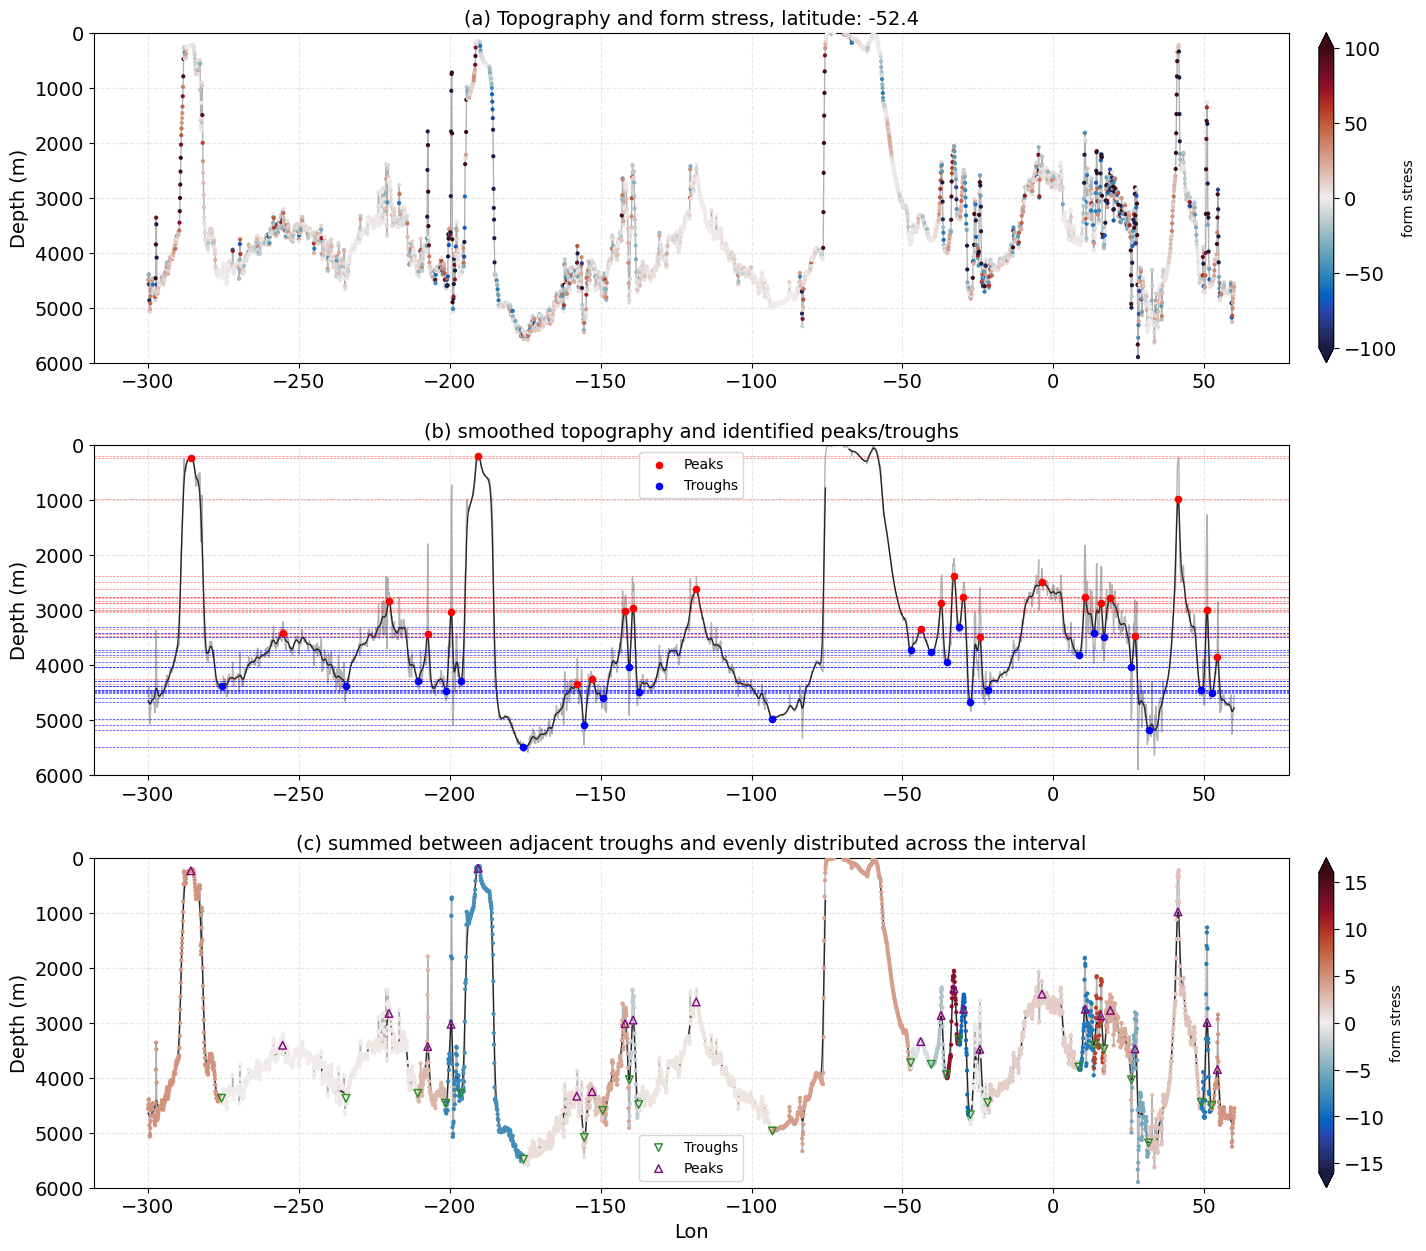

In [17]:
plt.close('all')

fig = plt.figure(figsize=(16, 15))

gs = GridSpec(3, 2, width_ratios=[80, 1], hspace=0.25, wspace=0.05)

ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[1, 0], sharex=None),
    fig.add_subplot(gs[2, 0], sharex=None)
]

cax1 = fig.add_subplot(gs[0, 1])
cax2 = fig.add_subplot(gs[2, 1])

# Form stress
ax[0].plot(geolon_u.isel(yh=yh_ind),depth_u.isel(yh=yh_ind),color='k',linewidth=1,alpha=0.3)

sc1 = ax[0].scatter(geolon_u.isel(yh=yh_ind),depth_u.isel(yh=yh_ind),c=x_in.isel(yh=yh_ind),cmap=cm.cm.balance,s=4,zorder=3,vmin=-100,vmax=100)

# cbar1 = plt.colorbar(sc1, ax=ax[0], extend='both')
cbar1 = plt.colorbar(sc1, cax=cax1, extend='both')
cbar1.set_label('form stress')

ax[0].grid(True, linestyle='--', alpha=0.3)
ax[0].set_ylim(0, 6000)
ax[0].invert_yaxis()
ax[0].set_ylabel('Depth (m)',fontsize=14)
ax[0].set_title('(a) Topography and form stress, latitude: %.1f'%geolat_u.isel(yh=yh_ind)[0],fontsize=14)

# identify peaks and troughs
ax[1].plot(geolon_u.isel(yh=yh_ind), depth_u.isel(yh=yh_ind), color='k', linewidth=1, alpha=0.3)
ax[1].plot(geolon_u.isel(yh=yh_ind), -e_smoothed, color='k', linewidth=1, alpha=0.8)

ax[1].scatter(geolon_u.isel(yh=yh_ind)[top_peaks],-e_smoothed[top_peaks],color='red',s=20,zorder=5,label='Peaks')
ax[1].scatter(geolon_u.isel(yh=yh_ind)[troughs],-e_smoothed[troughs],color='blue',s=20,zorder=5,label='Troughs')

for idx in top_peaks:
    ax[1].axhline(y=-e_smoothed[idx],color='r',linewidth=0.5,linestyle='--',alpha=0.5)

for idx in troughs:
    ax[1].axhline(y=-e_smoothed[idx],color='b',linewidth=0.5,linestyle='--',alpha=0.8)

ax[1].grid(True, linestyle='--', alpha=0.3)
ax[1].set_ylim(0, 6000)
ax[1].invert_yaxis()
ax[1].set_ylabel('Depth (m)',fontsize=14)
ax[1].legend()
ax[1].set_title('(b) smoothed topography and identified peaks/troughs',fontsize=14)
    
# Summed and evenly distributed
ax[2].plot(geolon_u.isel(yh=yh_ind),depth_u.isel(yh=yh_ind),color='k',linewidth=1,alpha=0.3)
ax[2].plot(geolon_u.isel(yh=yh_ind),-e_smoothed,color='k',linewidth=1,alpha=0.8)

ax[2].scatter(geolon_u.isel(yh=yh_ind)[troughs],-e_smoothed[troughs],marker='v',facecolors='none',edgecolor='forestgreen',s=30,zorder=5,label='Troughs')
ax[2].scatter(geolon_u.isel(yh=yh_ind)[peaks],-e_smoothed[peaks],marker='^',facecolors='none',edgecolor='purple',s=30,zorder=5,label='Peaks')

sc2 = ax[2].scatter(geolon_u.isel(yh=yh_ind),depth_u.isel(yh=yh_ind),c=x_distr,cmap=cm.cm.balance,s=4,zorder=3,vmin=-16,vmax=16)

# cbar2 = plt.colorbar(sc2, ax=ax[2], extend='both')
cbar2 = plt.colorbar(sc2, cax=cax2, extend='both')
cbar2.set_label('form stress')

ax[2].grid(True, linestyle='--', alpha=0.3)
ax[2].set_ylim(0, 6000)
ax[2].invert_yaxis()
ax[2].set_xlabel('Lon',fontsize=14)
ax[2].set_ylabel('Depth (m)',fontsize=14)
ax[2].set_title('(c) summed between adjacent troughs and evenly distributed across the interval',fontsize=14)
ax[2].legend()

# Increase tick label size
for a in ax:
    a.tick_params(axis='both', labelsize=14)

for cax in [cax1, cax2]:
    cax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('/g/data/nm03/lxy581/exps_figs/form_stress_8km_2layer_bc_x05_%.1f.png'%geolat_u.isel(yh=yh_ind)[0], dpi=300, bbox_inches='tight')